In [56]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/kminds-competition-1/sample_submission.csv
/kaggle/input/competitions/kminds-competition-1/train.csv
/kaggle/input/competitions/kminds-competition-1/test.csv


In [57]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
train = pd.read_csv("/kaggle/input/competitions/kminds-competition-1/train.csv")
print('shape:' ,train.shape)
print('columns:',train.columns)
print('\nDatatypes', train.dtypes)

train.head(10)

shape: (42380, 4)
columns: Index(['Id', 'Headline', 'Content', 'Label'], dtype='object')

Datatypes Id           int64
Headline    object
Content     object
Label        int64
dtype: object


,Id,Headline,Content,Label
0,1,কলকাতায় বোমা বিস্ফোরণে নিহত ১,ভারতের পশ্চিমবঙ্গের রাজধানী কলকাতায় একটি বাজার...,3
1,2,১৫ ঘণ্টা পর ময়মনসিংহের পথে ট্রেন চালু,ময়মনিসংহ স্টেশনের সুপারিনটেনডেন্ট জহিরুল হক জা...,2
2,3,ময়মনসিংহে আ.লীগের মামলায় আসামি ছাত্রলীগ,ময়মনসিংহ মহানগর আওয়ামী লীগের সভাপতি এহতেশামূল ...,3
3,4,পর্ণ দেখার শীর্ষে চট্টগ্রামের ছেলেরা,বন্দর নগরী চট্টগ্রামে পাশ্চাত্যের ছোঁয়া লেগেছ...,0
4,5,নড়াইলে কর্তব্যরত অবস্থায় পুলিশ সদস্যের মৃত্যু,নড়াইলের কালিয়ায় কর্তব্যরত অবস্থায় হৃদরোগে আক্র...,3
5,6,রোহিঙ্গাদের কারণে দূষিত হচ্ছে কক্সবাজারের পরিবেশ,দ্য রিপোর্ট প্রতিবেদক: রোহিঙ্গাদে কারণে কক্সবা...,3
6,7,কুষ্টিয়ায় সাব-রেজিস্ট্রার হত্যা: ২ কর্মচারী আটক,"কুষ্টিয়া মডেল থানার ওসি নাসির উদ্দিন জানান, এ ...",3
7,8,ফিলিপাইনের বিপক্ষে প্রথমার্ধে পিছিয়ে বাংলাদেশ,﻿কক্সবাজারের বঙ্গবন্ধু গোল্ডকাপের সেমিফাইনালের...,3
8,9,স্রষ্টা এই অসভ্য সরকারের উপর নাখোশ: কাদের,আজ মংগলবার হরতাল চলাকালে বিএনপি কার্যালয়ে বৃহ...,1
9,10,"বুধবার দিনটি যেমন কাটবে আপনার ০৯ অক্টোবর, ২০১৮...",আজ আপনার জন্ম দিন হলে পাশ্চাত্য মতে আপনার রাশি...,3


In [59]:
train.isnull().sum()

Id          0
Headline    0
Content     1
Label       0
dtype: int64

In [60]:
train['Label'].value_counts()

Label
3    34115
2     4629
1     2112
0     1524
Name: count, dtype: int64

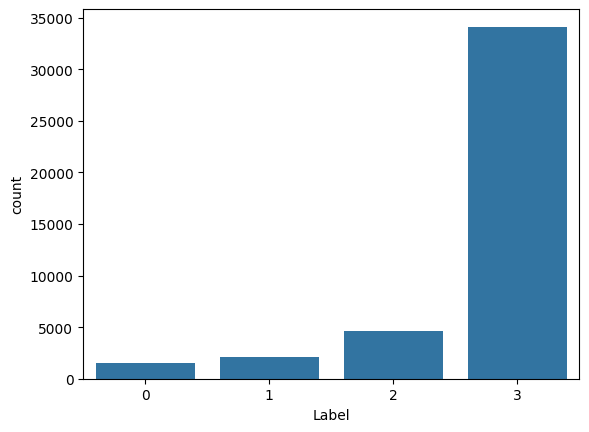

In [61]:
sns.countplot(x='Label',data=train)
plt.show()

Headline length stats :
 count    42380.000000
mean        45.509816
std         17.207476
min          1.000000
25%         35.000000
50%         43.000000
75%         53.000000
max        229.000000
Name: headline_len, dtype: float64

Content length stats :
 count    42380.000000
mean      1803.219372
std       1469.735812
min          3.000000
25%        941.000000
50%       1400.000000
75%       2137.000000
max      27155.000000
Name: content_len, dtype: float64


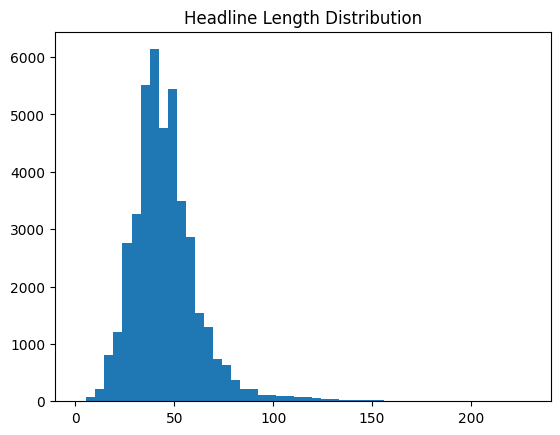

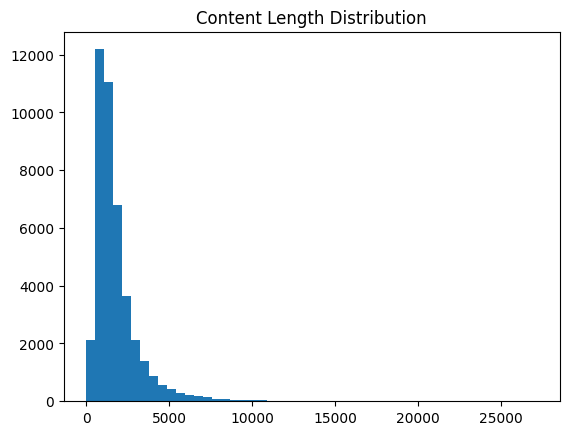

In [62]:
#creating texct length features to check the distribution 
train['headline_len']=train['Headline'].apply(len)
train['content_len']=train['Content'].apply(lambda x:len(str(x)))
print("Headline length stats :\n",train['headline_len'].describe())
print("\nContent length stats :\n",train['content_len'].describe())

plt.hist(train['headline_len'],bins=50)
plt.title("Headline Length Distribution")
plt.show()

plt.hist(train['content_len'],bins=50)
plt.title("Content Length Distribution")
plt.show()

In [63]:
# average length per class
print(train.groupby('Label')['headline_len'].mean())
print(train.groupby('Label')['content_len'].mean())

Label
0    54.596457
1    60.497159
2    53.236552
3    43.127627
Name: headline_len, dtype: float64
Label
0    1638.445538
1    1822.724432
2    1755.719162
3    1815.817910
Name: content_len, dtype: float64


In [64]:
print("full duplicate rows:",train.duplicated().sum())
print('Duplicate headlines:',train['Headline'].duplicated().sum())
print("Duplicate content:",train['Content'].duplicated().sum())
train[train['Headline'].duplicated(keep=False)].sort_values('Headline')[['Headline', 'Label']].head(10)

full duplicate rows: 0
Duplicate headlines: 3796
Duplicate content: 1418


,Headline,Label
30157,"""এতো মেকআপ করো কেন?"" এই প্রশ্নে বিরক্ত হয়ে প্র...",2
5136,"""এতো মেকআপ করো কেন?"" এই প্রশ্নে বিরক্ত হয়ে প্র...",2
31905,'অসমাপ্ত আত্মজীবনী'র স্প্যানিশ সংস্করণের মোড়ক ...,3
31968,'অসমাপ্ত আত্মজীবনী'র স্প্যানিশ সংস্করণের মোড়ক ...,3
32740,'আঙুল শতভাগ ঠিক না হলেও পারফর্মেন্সে প্রভাব পড়...,3
28009,'আঙুল শতভাগ ঠিক না হলেও পারফর্মেন্সে প্রভাব পড়...,3
32375,'আবার কোটা চাইলে আন্দোলন করেই পেতে হবে',3
24358,'আবার কোটা চাইলে আন্দোলন করেই পেতে হবে',3
41880,Avengers: Endgame এর টিকেট এর জন্য বসুন্ধরার স...,2
20022,Avengers: Endgame এর টিকেট এর জন্য বসুন্ধরার স...,2


In [65]:
label_counts=train['Label'].value_counts().sort_index()
print('label_counts')

label_percent=train['Label'].value_counts(normalize=True).sort_index()*100
print("\nLabel percentage %:",label_percent)


label_counts

Label percentage %: Label
0     3.596036
1     4.983483
2    10.922605
3    80.497876
Name: proportion, dtype: float64


In [66]:
#checking how many unique headlines and contents exist
print("Unique headlines:",train['Headline'].nunique())
print('Unique contents:',train['Content'].nunique())

print('\nHeadlines with length less than 5:')
print((train['headline_len']<=5).sum())

print('\nContents with length less then 20:')
print((train['content_len']<=20).sum())

train.loc[(train['headline_len'] <= 5) | (train['content_len'] <= 20),
          ['Id', 'Headline', 'Content', 'Label']].head(10)

Unique headlines: 38584
Unique contents: 40961

Headlines with length less than 5:
12

Contents with length less then 20:
3


,Id,Headline,Content,Label
2179,2180,কামড়,সিলেট মতিবেদক তারিখ ২৪০৫২০১১ আটক ব্যক্তি হাতকড়...,1
2720,2721,নী,"ইফ ইউ ডোন্ট মাইন্ড, লাভ দিস ফ্লাওয়ার। কতকাল পর...",3
3090,3091,গণিত,চার প্রক্রিয়া সম্পর্কিত সমস্যা ১। কোনো ছাত্রাব...,3
5585,5586,বাংলা,অনুচ্ছেদটি পড়ো ৩ ও ৪ নম্বর ক্রমিকের উত্তর দাও ...,3
7028,7029,,রাজধানীর শ্যামপুরে বড়ইতলা এলাকায় কাজ করার সময় ...,0
8301,8302,হতবাক,মতিচুর রহমান বিশিষ্ঠ ইসলামী চিন্তাবীদ আন্তর্জা...,1
16700,16701,জিম,জিমে কেন যাবেন জিমের প্রয়োজনীয়তা নিয়ে রেড জিমে...,3
16823,16824,0,। গর্বিত হও!যুক্তরাষ্ট্রের সেনাবাহিনীর একজন ভে...,0
19518,19519,গাছ!,"এক ফেসবুক বন্ধুর ওয়ালে দেখলাম, স্কলাস্টিকা স্ক...",3
24845,24846,গান,প্রতিদিনই শুনতে হয় কোনো না কোনো গান। মনের ওপর ...,3


In [67]:
# group by headline and count how many different labels each repeated headline has
headline_label_check = train.groupby('Headline')['Label'].nunique()

multi_label_headlines = headline_label_check[headline_label_check > 1]

print("Repeated headlines with more than one label:", len(multi_label_headlines))

train[train['Headline'].isin(multi_label_headlines.index)] \
    .sort_values('Headline')[['Headline', 'Label']] \
    .head(20)

Repeated headlines with more than one label: 1734


,Headline,Label
32469,ChotoBhai' এর ভিডিও রিপোর্ট করে takeout 2.0 থে...,0
15047,ChotoBhai' এর ভিডিও রিপোর্ট করে takeout 2.0 থে...,2
39563,Exclusive Interview: থ্যানোসের স্ন্যাপ থেকে বা...,2
19577,Exclusive Interview: থ্যানোসের স্ন্যাপ থেকে বা...,0
30144,Fake candidate: রেলের পরীক্ষায় বায়োমেট্রিকে ...,2
24379,Fake candidate: রেলের পরীক্ষায় বায়োমেট্রিকে ...,0
9962,SpaceX gives us a glimpse of its Mars base vision,3
24037,SpaceX gives us a glimpse of its Mars base vision,2
22206,eআরকি ইলেকশন সাজেশন : নিরপেক্ষ নির্বাচনের ১০টি...,2
30121,eআরকি ইলেকশন সাজেশন : নিরপেক্ষ নির্বাচনের ১০টি...,2


In [68]:

for label in sorted(train['Label'].unique()):
    print(f" Label {label}")
    display(train[train['Label'] == label][['Headline', 'Content']].head(3))

 Label 0


,Headline,Content
3,পর্ণ দেখার শীর্ষে চট্টগ্রামের ছেলেরা,বন্দর নগরী চট্টগ্রামে পাশ্চাত্যের ছোঁয়া লেগেছ...
12,টিকেট ছাড়া এই ঈদে বাড়ি যাওয়ার ৫টি বাংলা টিপস -...,ঈদ আসলে বাস-ট্রেন অগ্রীম টিকেট ছাড়ার সাথে সাথে...
35,এবার মাহফুজুর রহমানের গান শুনে হারানো স্মৃতি ফ...,সম্প্রতি একটি বেসরকারী টিভি চ্যানেলে প্রচারিত ...


 Label 1


,Headline,Content
8,স্রষ্টা এই অসভ্য সরকারের উপর নাখোশ: কাদের,আজ মংগলবার হরতাল চলাকালে বিএনপি কার্যালয়ে বৃহ...
46,করোনা উপসর্গ নিয়ে মৃত্যু: সিজিএসের রিপোর্ট ভুল...,বাংলাদেশের মূলধারার বেশ কয়েকটি সংবাদমাধ্যমে ২০...
60,একটি ব্রুটাল ইমেজ ’ ডোনাটে“ ওয়েইনস্টাইন” প্রচ...,ক্লিনটন ফাউন্ডেশনের একজন মুখপাত্র দাবি করেছেন ...


 Label 2


,Headline,Content
1,১৫ ঘণ্টা পর ময়মনসিংহের পথে ট্রেন চালু,ময়মনিসংহ স্টেশনের সুপারিনটেনডেন্ট জহিরুল হক জা...
14,৭ উইকেটে হারলো বাংলাদেশ!,টস জিতে ভারতীয় অধিনায়ক রোহিত শর্মা বাংলাদেশকে ...
20,ক্রোম ও ফায়ারফক্স ডাউনলোড করতে মাইক্রোসফটের সত...,সফটওয়্যার জায়ান্ট মাইক্রোসফট ইতিমধ্যে নিজেদের ...


 Label 3


,Headline,Content
0,কলকাতায় বোমা বিস্ফোরণে নিহত ১,ভারতের পশ্চিমবঙ্গের রাজধানী কলকাতায় একটি বাজার...
2,ময়মনসিংহে আ.লীগের মামলায় আসামি ছাত্রলীগ,ময়মনসিংহ মহানগর আওয়ামী লীগের সভাপতি এহতেশামূল ...
4,নড়াইলে কর্তব্যরত অবস্থায় পুলিশ সদস্যের মৃত্যু,নড়াইলের কালিয়ায় কর্তব্যরত অবস্থায় হৃদরোগে আক্র...


In [69]:
# check if Englis letters appear in headlines and in contns
train['has_english_headline'] = train['Headline'].str.contains(r'[A-Za-z]', regex=True, na=False)
train['has_english_content'] = train['Content'].astype(str).str.contains(r'[A-Za-z]', regex=True, na=False)

print("Headline rows with English letters (%):",
      train['has_english_headline'].mean() * 100)
print("Content rows with English letters (%):",
      train['has_english_content'].mean() * 100)

train.loc[
    train['has_english_headline'] | train['has_english_content'],
    ['Headline', 'Content', 'Label']
].head(10)

Headline rows with English letters (%): 1.2340726757904672
Content rows with English letters (%): 6.3166588013213785


,Headline,Content,Label
12,টিকেট ছাড়া এই ঈদে বাড়ি যাওয়ার ৫টি বাংলা টিপস -...,ঈদ আসলে বাস-ট্রেন অগ্রীম টিকেট ছাড়ার সাথে সাথে...,0
32,প্রতিরক্ষা মন্ত্রণালয়ে কাজের সুযোগ,নিয়োগ বিজ্ঞপ্তি দিয়েছে প্রতিরক্ষা মন্ত্রণালয়। ...,3
35,এবার মাহফুজুর রহমানের গান শুনে হারানো স্মৃতি ফ...,সম্প্রতি একটি বেসরকারী টিভি চ্যানেলে প্রচারিত ...,0
64,প্রেমিকা ছবিতে লাভ রিয়্যাক্ট না করাতেই ফেসবুক ...,জনপ্রিয় সোশ্যাল মিডিয়া প্লাটফর্ম ফেসবুকের স্বা...,0
82,ফ্যান বন্ধ করে বাকিখোর যুবকের হাত-পা বেধে বসিয...,গরমের তীব্রতায় দেশজুড়ে চলছে হাহাকার। ফ্যানের...,0
114,খেজুরের ঔষধি গুণ,সাধারণত রমজানে সবচেয়ে বেশি খেজুর খেয়ে থাকি আমর...,3
117,প্রেম করাতে পয়সা দিচ্ছেন প্রিয়াঙ্কা!,নিক জোনাসের সঙ্গে চুটিয়ে ডেট করছেন প্রিয়াঙ্কা ...,3
130,মেলায় হারিয়ে যাওয়া ভাইকে খুঁজে পেয়ে কান্নায় ভে...,‘গেম অফ থ্রোনস’ টিভি সিরিজের সিজন এইট মুক্তির ...,2
144,বাংলাদেশী প্রেমিককে নিজের দেশ ব্রাজিলে নিয়ে যা...,ShareTweetসামাজিক যোগাযোগ মাধ্যম ফেসবুকে পরিচয়...,2
152,নিজ রুমে পরীক্ষার্থীদের থাকার ব্যবস্থা করে খোল...,ঢাকা বিশ্ববিদ্যালয়ে ২০১৮-১৯ শিক্ষাবর্ষের ভর্ত...,2


In [70]:
# combine headline + content into one text column
train['text'] = train['Headline'] + " " + train['Content']

import re
def clean_text(text):
    text = str(text)  
    text = re.sub(r'\s+', ' ', text)  
    return text.strip()

train['text'] = train['text'].apply(clean_text)
train[['text', 'Label']].head()

,text,Label
0,কলকাতায় বোমা বিস্ফোরণে নিহত ১ ভারতের পশ্চিমবঙ্...,3
1,১৫ ঘণ্টা পর ময়মনসিংহের পথে ট্রেন চালু ময়মনিসংহ...,2
2,ময়মনসিংহে আ.লীগের মামলায় আসামি ছাত্রলীগ ময়মনসি...,3
3,পর্ণ দেখার শীর্ষে চট্টগ্রামের ছেলেরা বন্দর নগর...,0
4,নড়াইলে কর্তব্যরত অবস্থায় পুলিশ সদস্যের মৃত্যু ...,3


In [71]:
# converting text to numeric features using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,        
    ngram_range=(1,2)         
)

X = tfidf.fit_transform(train['text'])
y = train['Label']

print("X shape:", X.shape)

X shape: (42380, 5000)


In [72]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:20])   # first 20 words

['advertisement' 'bengal' 'com' 'eআরক' 'news' 'of' 'the' 'www' 'অক'
 'অক বর' 'অগ' 'অগ রগত' 'অগ রয' 'অগ রসর' 'অঙ' 'অঙ গন' 'অচ' 'অচল' 'অজ' 'অঞ']


In [73]:
# split data so we can test model performance before final submission
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,        
    random_state=42,      
    stratify=y            
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Training shape: (33904, 5000)
Validation shape: (8476, 5000)


In [74]:
# train a simple baseline model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)

from sklearn.metrics import f1_score

f1 = f1_score(y_val, y_pred, average='macro')
print("Validation Macro F1:", f1)

Validation Macro F1: 0.4655577661656533


In [75]:
from sklearn.svm import LinearSVC 
model=LinearSVC (class_weight='balanced')
model.fit(X_train,y_train)

y_pred=model.predict(X_val)

svm_f1=f1_score(y_val,y_pred,average='macro')
print("SVM macro F1:",svm_f1)

SVM macro F1: 0.49662231455060774


In [76]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train,y_train)

y_pred=model.predict(X_val)
lr_f1=f1_score(y_val,y_pred,average='macro')

print('LR Macro F1:',lr_f1)

LR Macro F1: 0.465498154740877


In [77]:
#improving TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.8
)
X=tfidf.fit_transform(train['text'])

In [78]:
from sklearn.model_selection import train_test_split

X_train,X_val,y_train,y_val=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.svm import LinearSVC
svm_model=LinearSVC(class_weight='balanced')
svm_model.fit(X_train,y_train)

svm_pred=svm_model.predict(X_val)

from sklearn.metrics import f1_score

svm_f1=f1_score(y_val,svm_pred,average='macro')
print("SVM Macro F1:",svm_f1)


SVM Macro F1: 0.5042996049903279


In [79]:
# evaluate where model is failing
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_val, svm_pred))
print(confusion_matrix(y_val, svm_pred))

              precision    recall  f1-score   support

           0       0.40      0.44      0.42       305
           1       0.32      0.33      0.32       422
           2       0.37      0.32      0.34       926
           3       0.93      0.94      0.93      6823

    accuracy                           0.82      8476
   macro avg       0.50      0.51      0.50      8476
weighted avg       0.82      0.82      0.82      8476

[[ 134   33   94   44]
 [  48  138  130  106]
 [ 115  156  300  355]
 [  38  107  291 6387]]


In [80]:
tfidf_char = TfidfVectorizer(
    max_features=20000,
    analyzer='char_wb',
    ngram_range=(3,5),
    min_df=3
)

X_char = tfidf_char.fit_transform(train['text'])
y = train['Label']

In [81]:
Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    X_char, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [82]:
svm_char = LinearSVC(class_weight='balanced')
svm_char.fit(Xc_train, yc_train)

pred_char = svm_char.predict(Xc_val)

In [83]:
f1_char = f1_score(yc_val, pred_char, average='macro')
print("Char TF-IDF SVM F1:", f1_char)

Char TF-IDF SVM F1: 0.5121205180248147


In [84]:
# combine word-level and character-level TF-IDF features
from scipy.sparse import hstack

tfidf_word = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=3
)

X_word = tfidf_word.fit_transform(train['text'])

tfidf_char = TfidfVectorizer(
    max_features=20000,
    analyzer='char_wb',
    ngram_range=(3,5),
    min_df=3
)

X_char = tfidf_char.fit_transform(train['text'])

X_combined = hstack([X_word, X_char])

y = train['Label']

print("Combined feature shape:", X_combined.shape)

Combined feature shape: (42380, 30000)


In [85]:
Xcom_train, Xcom_val, ycom_train, ycom_val = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# train anbd evaluate SVM on combined features
svm_combined = LinearSVC(class_weight='balanced')
svm_combined.fit(Xcom_train, ycom_train)

pred_combined = svm_combined.predict(Xcom_val)

f1_combined = f1_score(ycom_val, pred_combined, average='macro')
print("Combined Word+Char SVM F1:", f1_combined)

Combined Word+Char SVM F1: 0.508280799650867


In [86]:
# compute sample weights (inverse to class frequency)
from sklearn.utils.class_weight import compute_sample_weight

sample_w = compute_sample_weight(class_weight='balanced', y=y)

Xcom_train, Xcom_val, ycom_train, ycom_val, w_train, w_val = train_test_split(
    X_combined, y, sample_w,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# train SVM with sample weights
from sklearn.svm import LinearSVC

svm_sw = LinearSVC()  
svm_sw.fit(Xcom_train, ycom_train, sample_weight=w_train)

pred_sw = svm_sw.predict(Xcom_val)

f1_sw = f1_score(ycom_val, pred_sw, average='macro')
print("SVM (sample-weighted) F1:", f1_sw)

SVM (sample-weighted) F1: 0.48970845822950104


In [87]:
experiments = [
    {
        "name": "word_10k_1_2_min3",
        "analyzer": "word",
        "max_features": 10000,
        "ngram_range": (1,2),
        "min_df": 3
    },
    {
        "name": "word_20k_1_2_min3",
        "analyzer": "word",
        "max_features": 20000,
        "ngram_range": (1,2),
        "min_df": 3
    },
    {
        "name": "char_20k_3_5_min3",
        "analyzer": "char_wb",
        "max_features": 20000,
        "ngram_range": (3,5),
        "min_df": 3
    },
    {
        "name": "char_30k_3_6_min3",
        "analyzer": "char_wb",
        "max_features": 30000,
        "ngram_range": (3,6),
        "min_df": 3
    }
]

In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score
import pandas as pd

results = []

y = train['Label']

for exp in experiments:
    print("Running:", exp["name"])
    
    tfidf = TfidfVectorizer(
        analyzer=exp["analyzer"],
        max_features=exp["max_features"],
        ngram_range=exp["ngram_range"],
        min_df=exp["min_df"]
    )
    
    X = tfidf.fit_transform(train['text'])
    
    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    model = LinearSVC(class_weight='balanced')
    model.fit(X_train, y_train)
    
    pred = model.predict(X_val)
    f1 = f1_score(y_val, pred, average='macro')
    
    results.append([exp["name"], f1])

results_df = pd.DataFrame(results, columns=["Experiment", "Macro_F1"])
results_df.sort_values("Macro_F1", ascending=False)

Running: word_10k_1_2_min3
Running: word_20k_1_2_min3
Running: char_20k_3_5_min3
Running: char_30k_3_6_min3


,Experiment,Macro_F1
2,char_20k_3_5_min3,0.512121
3,char_30k_3_6_min3,0.505642
1,word_20k_1_2_min3,0.504056
0,word_10k_1_2_min3,0.503449


In [89]:
#test normalization
import re
def clean_text_v2(text):
    text = str(text)
    
    text = re.sub(r'[^\w\s]', ' ', text)
    
    text = re.sub(r'\d+', ' ', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

train['text_v2'] = train['text'].apply(clean_text_v2)

In [90]:
# TF-IDF using cleaned text_v2
tfidf_v2 = TfidfVectorizer(
    max_features=20000,
    analyzer='char_wb',
    ngram_range=(3,5),
    min_df=3
)

X_v2 = tfidf_v2.fit_transform(train['text_v2'])
y = train['Label']

Xv2_train, Xv2_val, yv2_train, yv2_val = train_test_split(
    X_v2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
svm_v2 = LinearSVC(class_weight='balanced')
svm_v2.fit(Xv2_train, yv2_train)

pred_v2 = svm_v2.predict(Xv2_val)

f1_v2 = f1_score(yv2_val, pred_v2, average='macro')
print("Cleaned Char TF-IDF SVM F1:", f1_v2)




Cleaned Char TF-IDF SVM F1: 0.5069333384081022


In [91]:
# FINAL SUBMISSION using best setup: Char TF-IDF + LinearSVC

import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

test = pd.read_csv('/kaggle/input/competitions/kminds-competition-1/test.csv')
sample = pd.read_csv('/kaggle/input/competitions/kminds-competition-1/sample_submission.csv')

test['text'] = test['Headline'].astype(str) + " " + test['Content'].astype(str)
test['text'] = test['text'].apply(clean_text)


In [92]:
# best TF-IDF setting
tfidf_final = TfidfVectorizer(
    max_features=20000,
    analyzer='char_wb',
    ngram_range=(3,5),
    min_df=3
)

# train on full training data
X_final = tfidf_final.fit_transform(train['text'])
y_final = train['Label']

X_test_final = tfidf_final.transform(test['text'])

final_model = LinearSVC(class_weight='balanced')
final_model.fit(X_final, y_final)

test_pred = final_model.predict(X_test_final)

submission = sample.copy()
submission['Label'] = test_pred

submission.to_csv('submission.csv', index=False)

submission.head()

,Id,Label
0,1,3
1,2,2
2,3,3
3,4,2
4,5,2
